In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

BASE=Path("../data")

In [3]:
nav=pd.read_csv(
BASE/"processed"/"clean_nav_history.csv"
)

perf=pd.read_csv(
BASE/"processed"/"clean_scheme_performance.csv"
)

tx=pd.read_csv(
BASE/"processed"/"clean_investor_transactions.csv"
)

portfolio=pd.read_csv(
BASE/"raw"/"09_portfolio_holdings.csv"
)

nav["date"]=pd.to_datetime(
nav["date"]
)

print(
nav.shape
)

(46000, 3)


In [ ]:
nav=nav.sort_values(
["amfi_code","date"]
)

nav["daily_return"]=(nav.groupby("amfi_code")["nav"].pct_change())

risk=[]

for code,g in nav.groupby("amfi_code"):

    r=g["daily_return"].dropna()

    var=np.percentile(r,5)

    cvar=r[r<=var].mean()
    risk.append([code,var,cvar])

risk=pd.DataFrame(
risk,columns=["amfi_code","VaR95","CVaR95"])

risk.head()

,amfi_code,VaR95,CVaR95
0,100016,-0.014364,-0.018060
1,100025,-0.003793,-0.004994
2,100033,-0.019034,-0.023456
3,101206,-0.013282,-0.017439
4,101207,-0.026021,-0.032459


In [5]:
risk.to_csv(
BASE/"processed"/"var_cvar_report.csv",
index=False
)

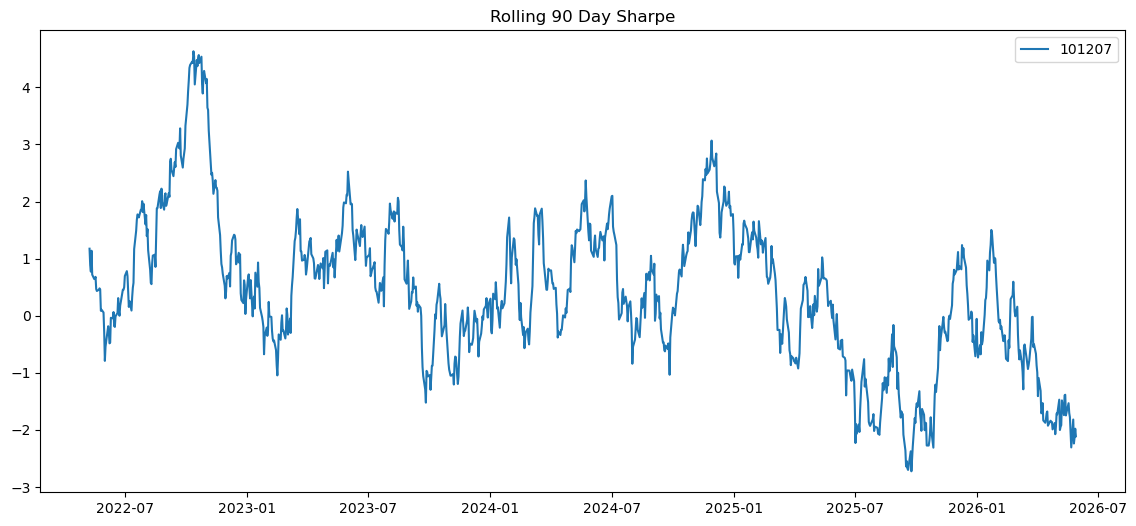

In [8]:
import numpy as np

top5=(
nav["amfi_code"]
.drop_duplicates()
.head(5)
)

plt.figure(
figsize=(14,6)
)

for code in top5:

    temp=nav[nav["amfi_code"]==code].copy()

    roll=(
temp["daily_return"].rolling(90).mean()
/
temp["daily_return"].rolling(90).std())* np.sqrt(252)
plt.plot(
temp["date"],roll,label=str(code)
)

plt.legend()

plt.title("Rolling 90 Day Sharpe")

plt.savefig(
"../reports/rolling_sharpe_chart.png"
)

plt.show()

In [10]:
tx["transaction_date"]=pd.to_datetime(tx["transaction_date"]
)

tx["cohort"]=(tx["transaction_date"].dt.year)
cohort=(
tx.groupby("cohort")

.agg(avg_sip=("amount_inr","mean"),

total=("amount_inr","sum"))
)

In [ ]:
sip=tx[tx["transaction_type"]=="SIP"
]

gap=(sip.sort_values(
["investor_id","transaction_date"]).groupby("investor_id")

["transaction_date"].diff().dt.days)
sip["gap"]=gap

risk_inv=(
sip.groupby("investor_id")
["gap"].mean() > 35)
risk_inv.value_counts()

Series([], Name: count, dtype: int64)

In [ ]:
import os

os.makedirs(
"../reports",exist_ok=True)

plt.savefig(
"../reports/rolling_sharpe_chart.png",bbox_inches="tight",dpi=300)
print("saved")

saved


<Figure size 640x480 with 0 Axes>